In [8]:
from google.colab import files

uploaded = files.upload()

Saving earthquake_1995-2023.csv to earthquake_1995-2023 (2).csv


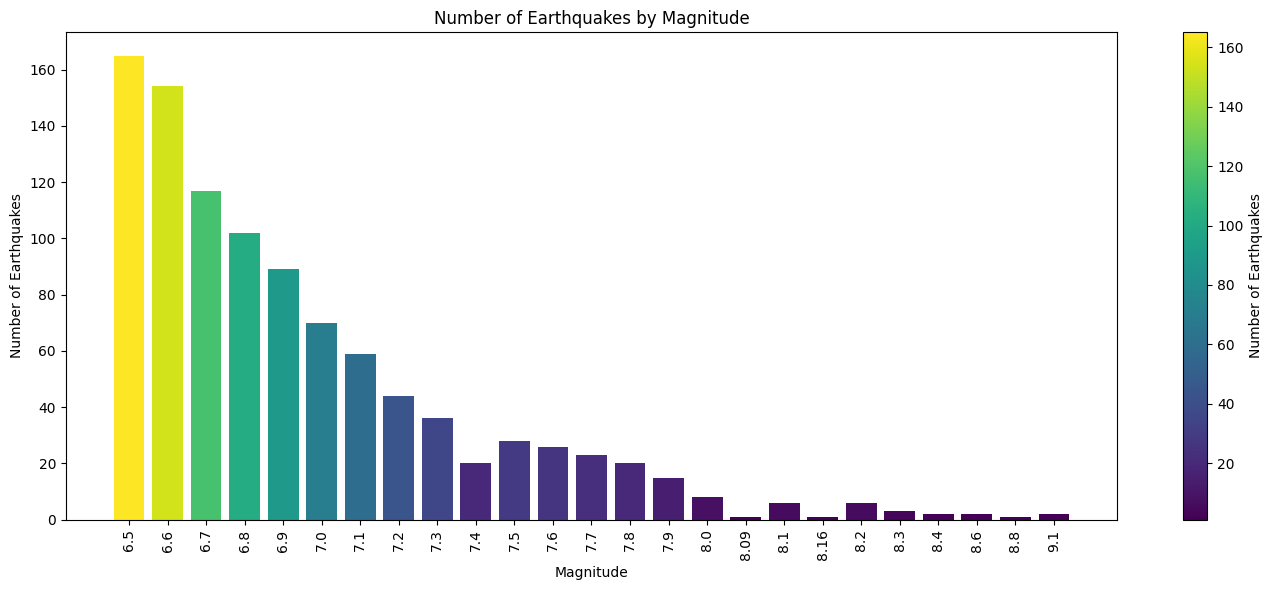

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

df = pd.read_csv("earthquake_1995-2023 (2).csv")

# Count earthquakes for each exact magnitude
mag_counts = df["magnitude"].value_counts().sort_index()

# Normalize number of earthquakes
norm = colors.Normalize(
    vmin=mag_counts.values.min(),
    vmax=mag_counts.values.max()
)

# Create colors based on number of earthquakes
cmap = cm.viridis
bar_colors = cmap(norm(mag_counts.values))

# Create bar plot
plt.figure(figsize=(14, 6))

plt.bar(
    mag_counts.index.astype(str),
    mag_counts.values,
    color=bar_colors
)

plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.title("Number of Earthquakes by Magnitude")
plt.xticks(rotation=90)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Number of Earthquakes")

plt.tight_layout()
plt.show()

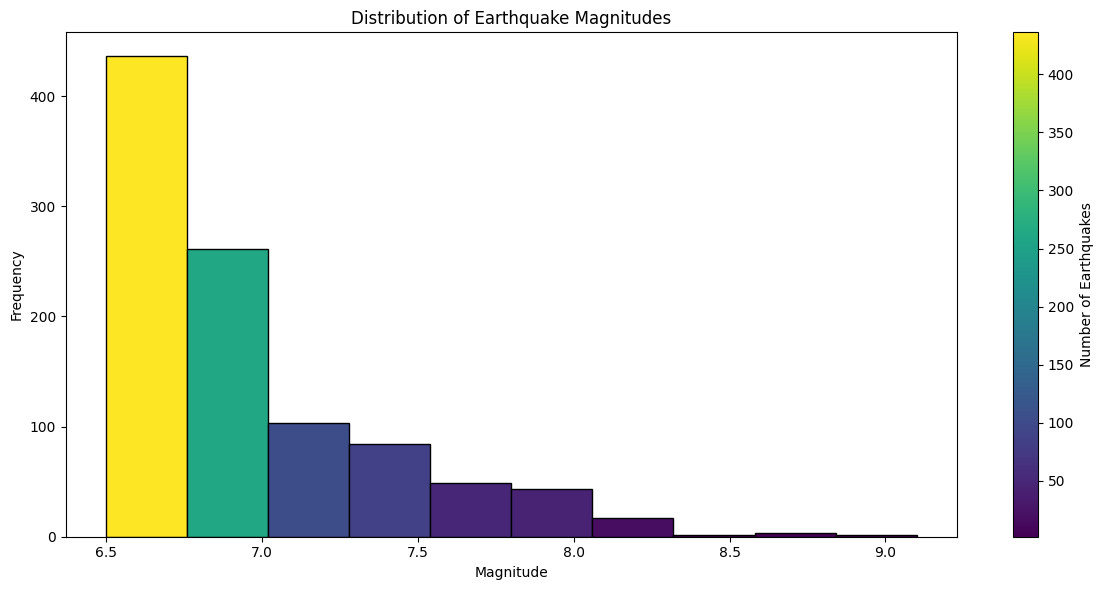

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

df = pd.read_csv("earthquake_1995-2023 (2).csv")

# Calculate histogram values
counts, bins = np.histogram(df["magnitude"], bins=10)

# Normalize frequency values
norm = colors.Normalize(vmin=counts.min(), vmax=counts.max())

# Create colors based on frequency
cmap = cm.viridis
bar_colors = cmap(norm(counts))

# Create histogram
plt.figure(figsize=(12, 6))

n, bins_hist, patches = plt.hist(
    df["magnitude"],
    bins=bins,
    edgecolor="black"
)

# Apply individual colors to each bar
for i, patch in enumerate(patches):
    patch.set_facecolor(bar_colors[i])

plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Magnitudes")

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Number of Earthquakes")

plt.tight_layout()
plt.show()

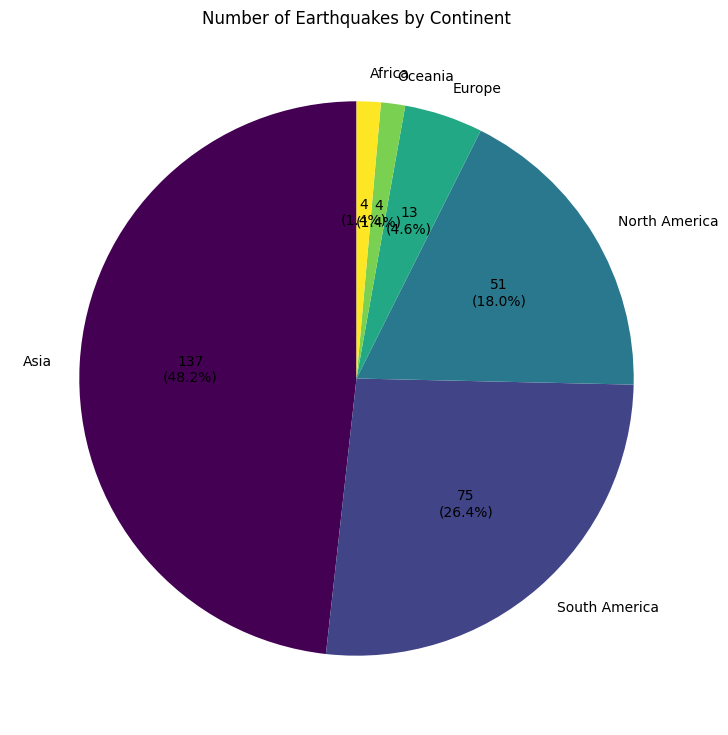

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.read_csv("earthquake_1995-2023 (2).csv")

# Count earthquakes by continent
continent_count = df["continent"].value_counts()

# Colormap
colors = cm.viridis(np.linspace(0, 1, len(continent_count)))

# Show both number and percentage
def show_count_and_percentage(pct):
    total = continent_count.sum()
    count = int(round(pct * total / 100))
    return f"{count}\n({pct:.1f}%)"

# Pie chart
plt.figure(figsize=(9, 9))

plt.pie(
    continent_count.values,
    labels=continent_count.index,
    colors=colors,
    autopct=show_count_and_percentage,
    startangle=90
)

plt.title("Number of Earthquakes by Continent")
plt.show()

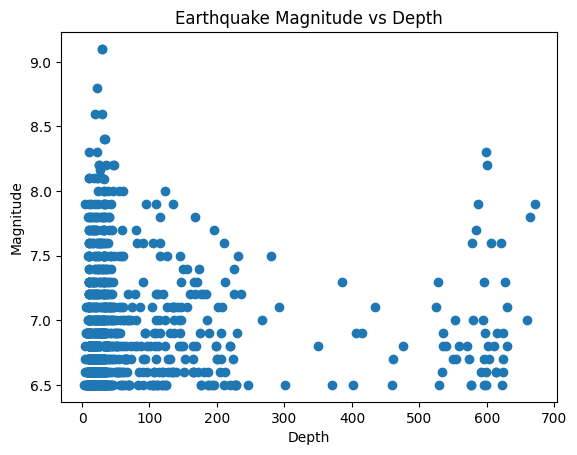

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["depth"], df["magnitude"])
plt.xlabel("Depth")
plt.ylabel("Magnitude")
plt.title("Earthquake Magnitude vs Depth")
plt.show()

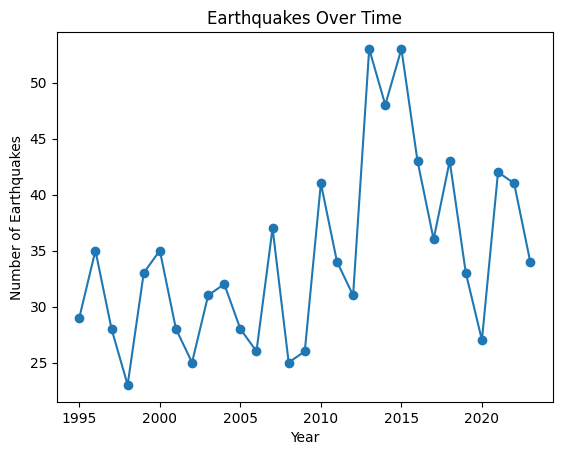

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df["date_time"] = pd.to_datetime(df["date_time"], dayfirst=True)

yearly_count = df.groupby(df["date_time"].dt.year).size()

plt.plot(yearly_count.index, yearly_count.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquakes Over Time")
plt.show()